## Лабораторна робота №4

**Виконали:**   
   
Варіант 2
- Сачек Владислава, КА-31
- Богданова Олександра, КА-32
- Плахтій Злата, КА-32

**Хід виконання роботи:**
1. Завантажити два набори зображень згiдно з варiантом: чорно-бiлi (дивiться попереднiй практикум) та кольоровi. Якщо набiр великого розмiру, можна обрати частину.
2. Пiдготувати данi для навчання - за необхiдностi.
3. Роздiлити данi на навчальну, перевiрочну i тестову пiдмножини.
4. Побудувати i навчити базову модель з одним згортковим шаром. Оцiнити правильнiсть (accuracy) та точнiсть моделi на тренувальнiй i перевiрочнiй множинах.
5. Дослiдити рiзнi значення параметрiв padding i strides згорткового шару базової моделi, а також розмiрнiсть ядра (kernel) згортки та їх вплив на точнiсть моделi. На перевiрочнiй множинi обрати значення вказаних параметрiв.
6. Дослiдити кiлька альтернативних архiтектур згорткових моделей, якi включають:
- кiлька згорткових шарiв,
- шар/ шари нормалiзацiї за мiнi-батчами,
- шар/ шари дропауту.   
На перевiрочнiй множинi оцiнити якiсть побудованих моделей i обрати найкращу архiтектуру. Використати показники якостi: accuracy, precision, recall, f1-score, AUC.
7. Чи впливає на правильнiсть (accuracy) моделi додавання регуляризацiї: дропаут, рання зупинка навчання, та використання рiзних методiв iнiцiалiзацiї ваг?
8. Вiдобразити у TensorBoard графiки, якi iлюструють оцiнки якостi навчання мереж на навчальнiй та перевiрочнiй множинах:
- графiки змiни функцiї втрат на тренувальнiй i перевiрочнiй множинах по мiрi навчання моделей,
- графiки змiни правильностi моделi на тренувальнiй i перевiрочнiй множинах по мiрi навчання моделей.
9. Розрахувати на тестовiй множинi оцiнки якостi обраної найкращої моделi.
10. Завантажити зображення тестової множини i розпiзнати його навченими моделями.
11. Порiвняти побудованi згортковi моделi та багатошаровий персептрон в задачi класифiкацiї чорно-бiлих та кольорових зображень. Виконати класифікацію кольорових зображень також багатошаровим персептроном. 
Експериментальним шляхом показати що згорткові моделі, дійсно, краще за MLP виконують їх класифікацію.
Чорно-білі зображення (з практикуму 2) згортковою моделлю - по бажанню.
12. Зробити висновки щодо якостi класифiкацiї на основi побудованих моделей.

**Набір даних:** Rice Image Dataset (кольорові зображення)

### Імпорт бібліотек

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, Input)

### Завантаження набору кольорових зображень Rice Image Dataset

In [2]:
DATA_DIR = "./Rice_Image_Dataset"

IMG_SIZE = 64
BATCH_SIZE = 64

### Підготовка даних та розділення на навчальну, перевiрочну i тестову пiдмножини

Набір містить 75 000 кольорових зображень зерен рису п'яти сортів **Arborio**, **Basmati**, **Ipsala**, **Jasmine**, **Karacadag**.    
Нехай розділення: 
- **train (60%)** - навчальна множина
- **val (20%)** - перевірочна множина
- **test (20%)** - тестова множина

Завантаження виконуємо за допомогою tf.keras.utils.image_dataset_from_directory, що автоматично зчитує зображення з підпапок, формує мітки за іменами папок та групує дані в батчі по 64. 

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="categorical",
    validation_split=0.4, subset="training", seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="categorical",
    validation_split=0.4, subset="validation", seed=42
)

val_batches = len(val_ds)
test_size = val_batches // 2

test_ds = val_ds.skip(test_size)
val_ds  = val_ds.take(test_size)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f"Класи: {CLASS_NAMES}")
print(f"Кількість класів: {NUM_CLASSES}")
print(f"Train батчів: {len(train_ds)}, Val батчів: {len(val_ds)}, Test батчів: {len(test_ds)}")

Found 75000 files belonging to 5 classes.
Using 45000 files for training.
Found 75000 files belonging to 5 classes.
Using 30000 files for validation.
Класи: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Кількість класів: 5
Train батчів: 704, Val батчів: 234, Test батчів: 235


In [4]:
train_ds = train_ds.take(len(train_ds) // 3)
val_ds   = val_ds.take(len(val_ds) // 3)
test_ds  = test_ds.take(len(test_ds) // 3)

print(f"Після скорочення: Train батчів: {len(train_ds)}, "
      f"Val батчів: {len(val_ds)}, Test батчів: {len(test_ds)}")

Після скорочення: Train батчів: 234, Val батчів: 78, Test батчів: 78


Виконуємо нормалізацію пікселів до [0, 1] через шар `Rescaling` і для прискорення повторних епох застосовуємо .cache().prefetch():

In [5]:
# Нормалізація пікселів [0, 255] -> [0, 1]
normalization = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization(x), y))

# Оптимізація завантаження даних
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Візуалізація прикладів зображень

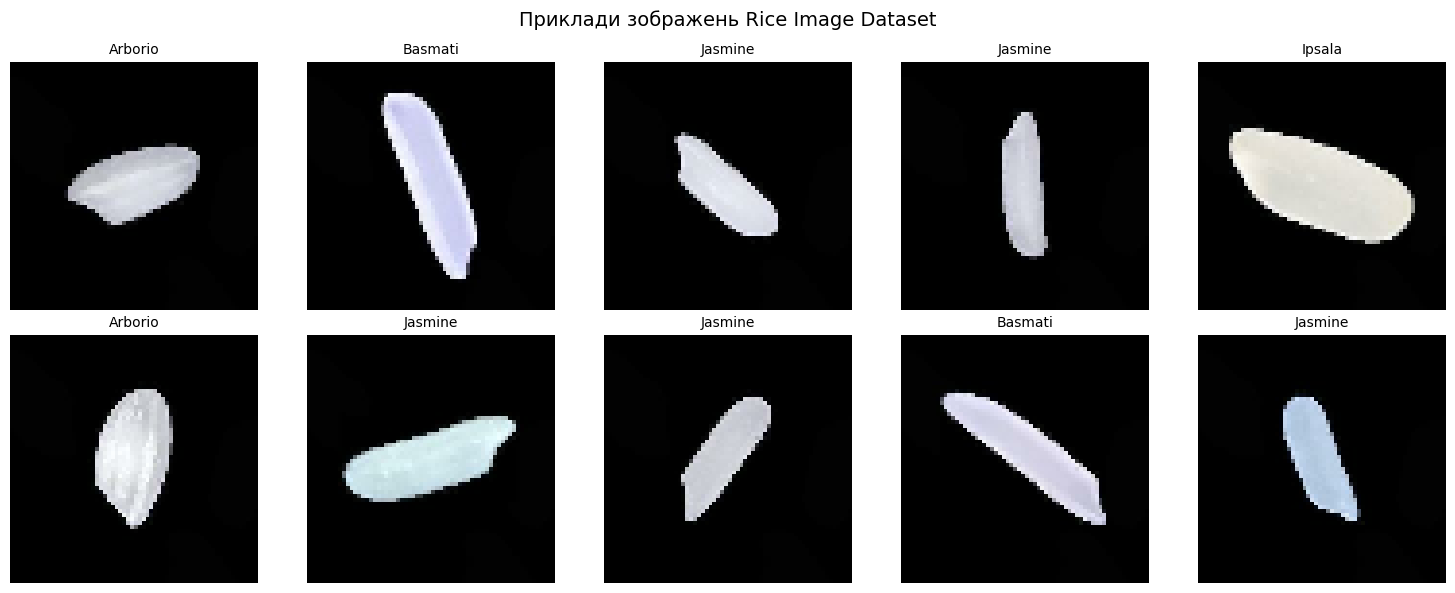

In [6]:
images, labels = next(iter(train_ds))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(images[i].numpy())
    class_idx = np.argmax(labels[i])
    ax.set_title(CLASS_NAMES[class_idx], fontsize=10)
    ax.axis("off")
plt.suptitle("Приклади зображень Rice Image Dataset", fontsize=14)
plt.tight_layout()
plt.show()

### Базова модель з одним згортковим шаром
Побудуємо базову CNN з одним згортковим шаром: Input(64×64×3) -> Conv2D(32, 3×3, same, relu) -> MaxPooling2D(2×2) -> Flatten -> Dense(5, softmax). Модель навчається протягом 20 епох з оптимізатором Adam та функцією втрат categorical crossentropy.

In [7]:
EPOCHS = 20

def build_base_model(filters=32, kernel_size=(3,3), padding='same', strides=(1,1)):
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(filters, kernel_size, padding=padding, strides=strides, activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

base_model = build_base_model()
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │       163,845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,741 (643.52 KB)

 Trainable params: 164,741 (643.52 KB)

 Non-trainable params: 0 (0.00 B)

### Навчання базової моделі

In [8]:
history_base = base_model.fit(
    train_ds,
    epochs=EPOCHS, validation_data=val_ds, verbose=1
)

Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.9144 - loss: 0.2595 - val_accuracy: 0.9615 - val_loss: 0.1228
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9697 - loss: 0.0974 - val_accuracy: 0.9696 - val_loss: 0.0912
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9810 - loss: 0.0640 - val_accuracy: 0.9694 - val_loss: 0.0885
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9840 - loss: 0.0553 - val_accuracy: 0.9615 - val_loss: 0.1113
Epoch 5/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9854 - loss: 0.0492 - val_accuracy: 0.9553 - val_loss: 0.1210
Epoch 6/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9846 - loss: 0.0475 - val_accuracy: 0.9754 - val_loss: 0.0700
Epoch 7/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9882 - loss: 0.0402 - val_accuracy: 0.9690 - val_loss: 0.0823
Epoch 8/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9888 - loss: 0.0377 - val_acc

Модель демонструє ознаки незначного перенавчання: train accuracy зростає до майже 1.0, тоді як val accuracy стабілізується на рівні ~0.985.

### Графіки навчання базової моделі

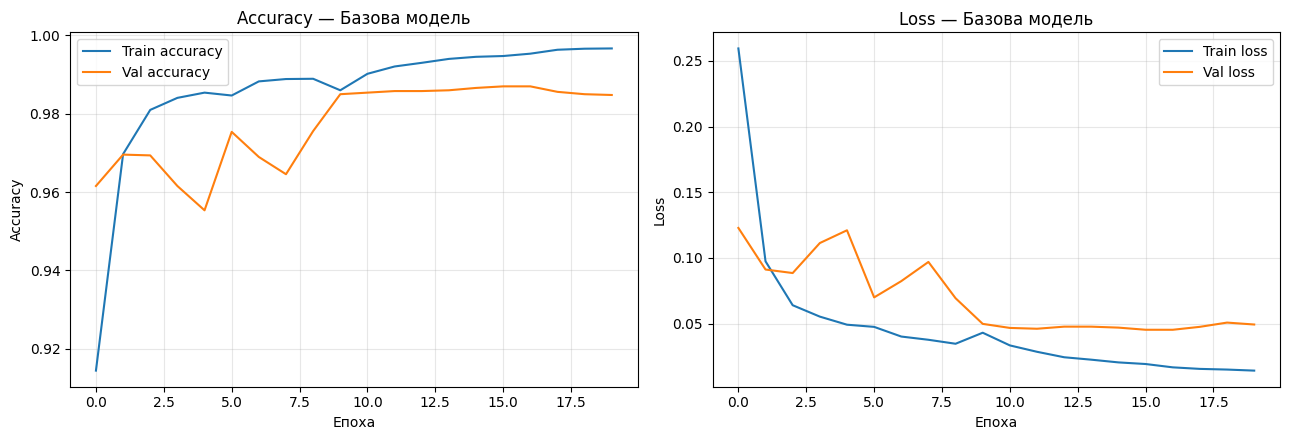

In [9]:
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax1.plot(history.history['accuracy'], label='Train accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val accuracy')
    ax1.set_xlabel('Епоха'); ax1.set_ylabel('Accuracy')
    ax1.set_title(f'Accuracy — {title}')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'], label='Train loss')
    ax2.plot(history.history['val_loss'], label='Val loss')
    ax2.set_xlabel('Епоха'); ax2.set_ylabel('Loss')
    ax2.set_title(f'Loss — {title}')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_base, "Базова модель")

### Оцінка базової моделі

In [12]:
train_loss, train_acc = base_model.evaluate(train_ds, verbose=0)
val_loss, val_acc = base_model.evaluate(val_ds, verbose=0)

print(f"Базова модель:")
print(f"  Train — loss: {train_loss:.4f}, accuracy: {train_acc:.4f}")
print(f"  Val   — loss: {val_loss:.4f}, accuracy: {val_acc:.4f}")

Базова модель:
  Train — loss: 0.0099, accuracy: 0.9973
  Val   — loss: 0.0493, accuracy: 0.9848


### Дослідження параметрів згорткового шару

Дослідимо вплив на якість моделі:
- **padding**: 'same' vs 'valid'
- **strides**: (1,1) vs (2,2)
- **kernel_size**: (3,3), (5,5), (7,7)

#### Вплив параметра padding


padding='same'
  Train acc: 0.9977, Val acc: 0.9856

padding='valid'
  Train acc: 0.9975, Val acc: 0.9898


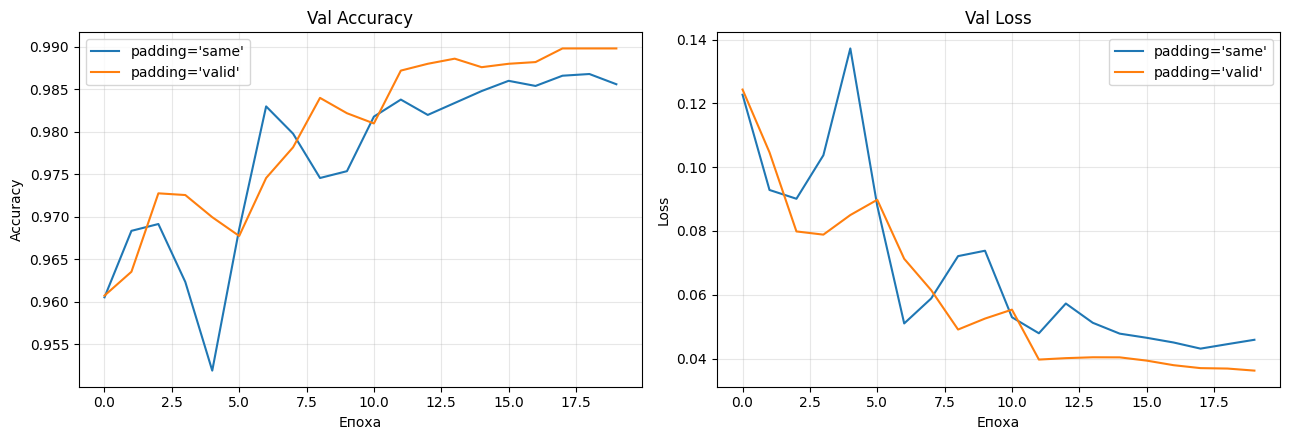

In [13]:
results = []

for pad in ['same', 'valid']:
    print(f"\npadding='{pad}'")
    model = build_base_model(padding=pad)
    hist = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=0)
    t_loss, t_acc = model.evaluate(train_ds, verbose=0)
    v_loss, v_acc = model.evaluate(val_ds, verbose=0)
    results.append({
        'param': 'padding', 'value': pad,
        'train_acc': t_acc, 'val_acc': v_acc,
        'train_loss': t_loss, 'val_loss': v_loss,
        'history': hist
    })
    print(f"  Train acc: {t_acc:.4f}, Val acc: {v_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for r in results:
    ax1.plot(r['history'].history['val_accuracy'], label=f"padding='{r['value']}'")
    ax2.plot(r['history'].history['val_loss'], label=f"padding='{r['value']}'")
ax1.set_title('Val Accuracy'); ax1.set_xlabel('Епоха')
ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title('Val Loss'); ax2.set_xlabel('Епоха')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Padding valid, який зменшує просторову розмірність, показав дещо кращий результат на цьому наборі даних.

#### Вплив параметра strides


strides=(1, 1)
  Train acc: 0.9969, Val acc: 0.9860

strides=(2, 2)
  Train acc: 0.9945, Val acc: 0.9888


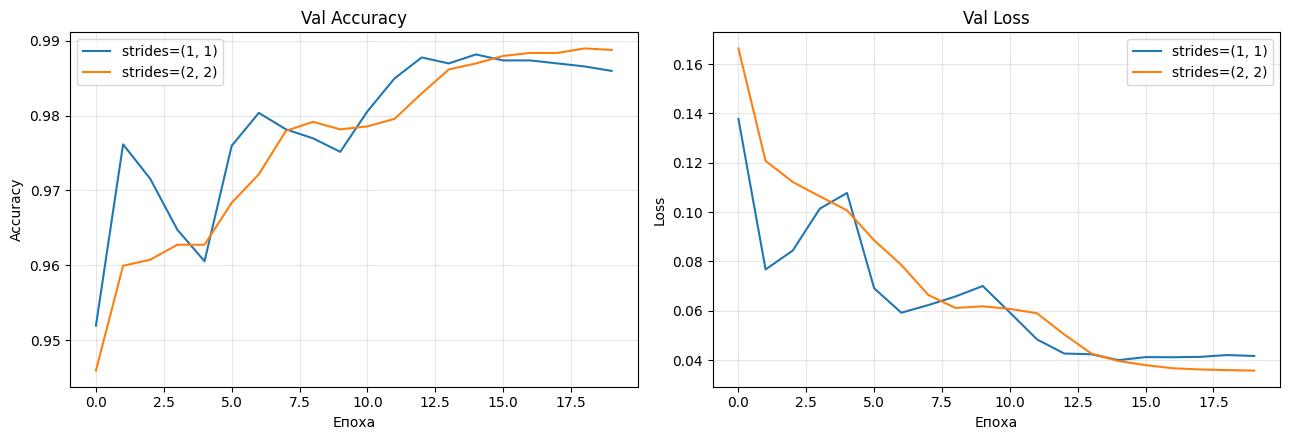

In [14]:
for stride in [(1,1), (2,2)]:
    print(f"\nstrides={stride}")
    model = build_base_model(strides=stride)
    hist = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=0)
    t_loss, t_acc = model.evaluate(train_ds, verbose=0)
    v_loss, v_acc = model.evaluate(val_ds, verbose=0)
    results.append({
        'param': 'strides', 'value': str(stride),
        'train_acc': t_acc, 'val_acc': v_acc,
        'train_loss': t_loss, 'val_loss': v_loss,
        'history': hist
    })
    print(f"  Train acc: {t_acc:.4f}, Val acc: {v_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for r in results:
    if r['param'] == 'strides':
        ax1.plot(r['history'].history['val_accuracy'], label=f"strides={r['value']}")
        ax2.plot(r['history'].history['val_loss'], label=f"strides={r['value']}")
ax1.set_title('Val Accuracy'); ax1.set_xlabel('Епоха')
ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title('Val Loss'); ax2.set_xlabel('Епоха')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Збільшений крок (2,2) показав трохи вищу val accuracy, одночасно суттєво прискоривши навчання.

#### Вплив розмірності ядра


kernel_size=(3, 3)
  Train acc: 0.9969, Val acc: 0.9844

kernel_size=(5, 5)
  Train acc: 0.9943, Val acc: 0.9818

kernel_size=(7, 7)
  Train acc: 0.9935, Val acc: 0.9798


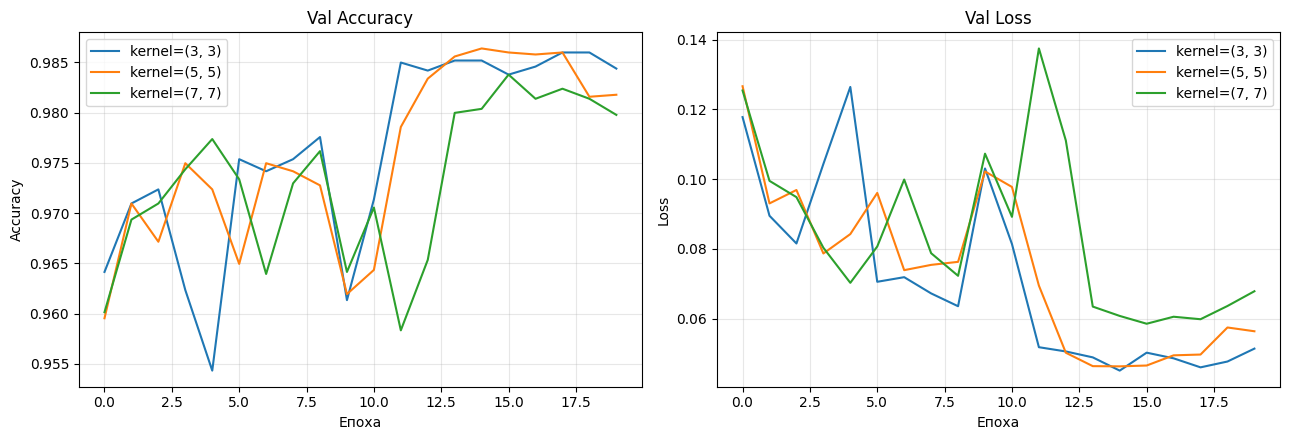

In [15]:
for ks in [(3,3), (5,5), (7,7)]:
    print(f"\nkernel_size={ks}")
    model = build_base_model(kernel_size=ks)
    hist = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=0)
    t_loss, t_acc = model.evaluate(train_ds, verbose=0)
    v_loss, v_acc = model.evaluate(val_ds, verbose=0)
    results.append({
        'param': 'kernel_size', 'value': str(ks),
        'train_acc': t_acc, 'val_acc': v_acc,
        'train_loss': t_loss, 'val_loss': v_loss,
        'history': hist
    })
    print(f"  Train acc: {t_acc:.4f}, Val acc: {v_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for r in results:
    if r['param'] == 'kernel_size':
        ax1.plot(r['history'].history['val_accuracy'], label=f"kernel={r['value']}")
        ax2.plot(r['history'].history['val_loss'], label=f"kernel={r['value']}")
ax1.set_title('Val Accuracy'); ax1.set_xlabel('Епоха')
ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title('Val Loss'); ax2.set_xlabel('Епоха')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Найменше ядро 3×3 показало найкращий результат, зі збільшенням розміру ядра якість поступово знижується.

In [16]:
import pandas as pd

rows = []
for r in results:
    rows.append({
        'Параметр': r['param'],
        'Значення': r['value'],
        'Train Accuracy': f"{r['train_acc']:.4f}",
        'Val Accuracy': f"{r['val_acc']:.4f}",
        'Train Loss': f"{r['train_loss']:.4f}",
        'Val Loss': f"{r['val_loss']:.4f}",
    })

df_results = pd.DataFrame(rows)
display(df_results)

print("\nНайкраща конфігурація за Val Accuracy по кожному параметру:")
for param in ['padding', 'strides', 'kernel_size']:
    subset = df_results[df_results['Параметр'] == param]
    best_idx = subset['Val Accuracy'].astype(float).idxmax()
    best = df_results.iloc[best_idx]
    print(f"{best['Параметр']} = {best['Значення']}, Val Accuracy = {best['Val Accuracy']}")

,Параметр,Значення,Train Accuracy,Val Accuracy,Train Loss,Val Loss
0,padding,same,0.9977,0.9856,0.0086,0.0459
1,padding,valid,0.9975,0.9898,0.0093,0.0362
2,strides,"(1, 1)",0.9969,0.9860,0.0105,0.0417
3,strides,"(2, 2)",0.9945,0.9888,0.0193,0.0358
4,kernel_size,"(3, 3)",0.9969,0.9844,0.0105,0.0514
5,kernel_size,"(5, 5)",0.9943,0.9818,0.0158,0.0564
6,kernel_size,"(7, 7)",0.9935,0.9798,0.0164,0.0678



Найкраща конфігурація за Val Accuracy по кожному параметру:
padding = valid, Val Accuracy = 0.9898
strides = (2, 2), Val Accuracy = 0.9888
kernel_size = (3, 3), Val Accuracy = 0.9844


#### Найкраща базова модель з обраними параметрами

На основі проведених експериментів обираємо найкращі значення параметрів та навчаємо фінальну базову модель.

Обрані параметри: padding='valid', strides=(2, 2), kernel_size=(3, 3)
Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8786 - loss: 0.3590 - val_accuracy: 0.9469 - val_loss: 0.1685
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9559 - loss: 0.1409 - val_accuracy: 0.9585 - val_loss: 0.1265
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9649 - loss: 0.1100 - val_accuracy: 0.9635 - val_loss: 0.1130
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9713 - loss: 0.0916 - val_accuracy: 0.9661 - val_loss: 0.1062
Epoch 5/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9741 - loss: 0.0800 - val_accuracy: 0.9641 - val_loss: 0.1055
Epoch 6/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9776 - loss: 0.0721 - val_accuracy: 0.9677 - val_loss: 0.0943
Epoch 7/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9798 - loss: 0.0660 - val_accuracy: 0.9740 - val_loss: 0.0811
Epoch 8/20
234/234 ━━━━━━━━

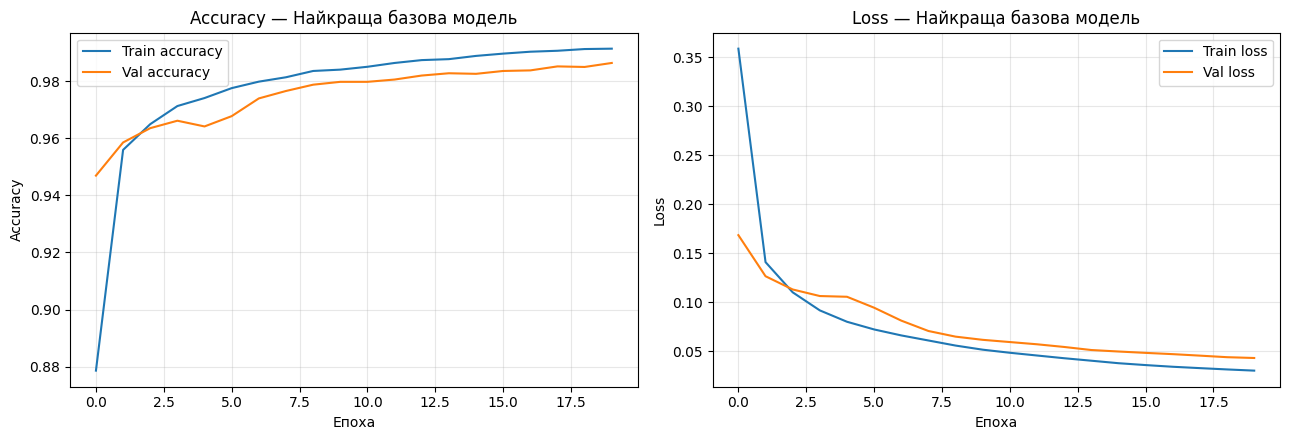


Найкраща базова модель — Val accuracy: 0.9864, Val loss: 0.0429


In [17]:
BEST_PADDING = 'valid'
BEST_STRIDES = (2, 2)
BEST_KERNEL  = (3, 3)

print(f"Обрані параметри: padding='{BEST_PADDING}', "
      f"strides={BEST_STRIDES}, kernel_size={BEST_KERNEL}")

best_base_model = build_base_model(
    padding=BEST_PADDING, strides=BEST_STRIDES, kernel_size=BEST_KERNEL
)

history_best_base = best_base_model.fit(
    train_ds,
    epochs=EPOCHS, validation_data=val_ds, verbose=1
)

plot_history(history_best_base, "Найкраща базова модель")

v_loss, v_acc = best_base_model.evaluate(val_ds, verbose=0)
print(f"\nНайкраща базова модель — Val accuracy: {v_acc:.4f}, Val loss: {v_loss:.4f}")

Даний датасет містить зображення зерен рису здебільшого дуже світлих відтінків на чорному фоні, тому padding='valid' і strides=(2,2) не погіршили результат, для таких однорідних зображень втрата деталей при зменшенні розмірності не критична.   
Моделі легко "запам'ятати" тренувальні приклади, бо відмінностей між зображеннями всередині класу мало, а між класами - нюанси форми та відтінку, тому у моделі є перенавчання, але незначне.